### Exercise

- Train SVM with linear kernel, LogisticRegression, KNN, Naibe Bayes and Decision tree classifiers on this dataset. With and without dimensionality reduction.
- What is the accuracy obtained on the test set?
- Show the classification report
- Show the confusion matrix

We will compare five classifiers:

1. Linear SVM
2. Logistic Regression
3. KNN
4. Naive Bayes
5. Decision Tree

We will train them:

1. Without dimensionality reduction
2. With PCA dimensionality reduction using eigenfaces

Then we will compare:

1. Accuracy
2. Classification report
3. Confusion matrix

In [1]:
# Import all the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load the faces dataset

faces = fetch_lfw_people(min_faces_per_person=60)

print("Target names:")
print(faces.target_names)

print("Images shape:")
print(faces.images.shape)

print("Data shape:")
print(faces.data.shape)

print("Target shape:")
print(faces.target.shape)


Target names:
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
Images shape:
(1348, 62, 47)
Data shape:
(1348, 2914)
Target shape:
(1348,)


In [3]:
X = faces.data #features
y = faces.target #label

target_names = faces.target_names
n_classes = len(target_names)

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes:", n_classes)

Number of samples: 1348
Number of features: 2914
Number of classes: 8


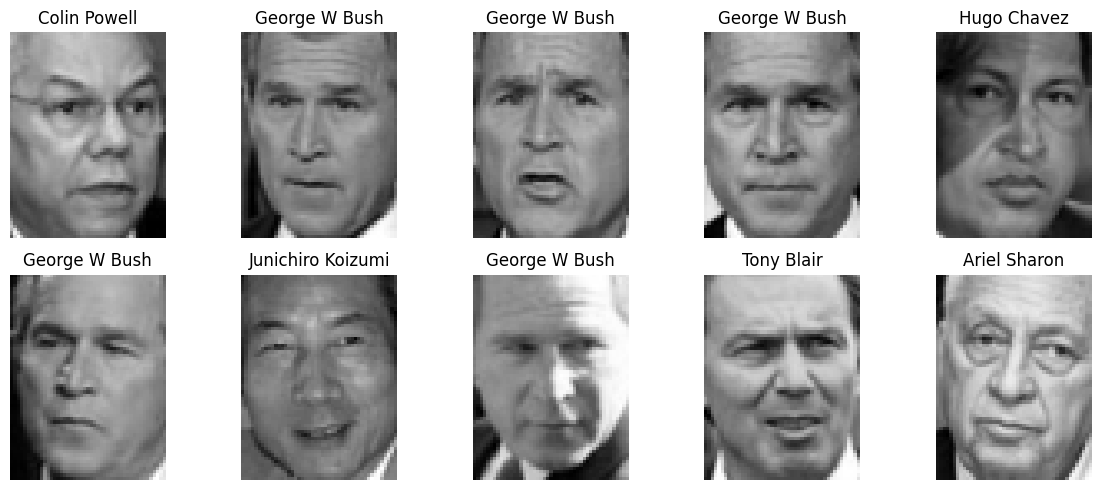

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, image, label in zip(axes.ravel(), faces.images, faces.target):
    ax.imshow(image, cmap='gray')
    ax.set_title(target_names[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [5]:
# split training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y #ensure fair distribution
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (1011, 2914)
Test shape: (337, 2914)


In [6]:
# define classifiers

classifiers = {
    "Linear SVM": SVC(kernel='linear', random_state=42), #find a boundary that separates the faces
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42), #learn face probabilities
    "KNN": KNeighborsClassifier(n_neighbors=5), #classifies based on nearby examples
    "Naive Bayes": GaussianNB(), #use probability assumptions
    "Decision Tree": DecisionTreeClassifier(random_state=42) #uses decision rules based on face values
}



In [9]:
#Without dimensionality reduction and without PCA

results_without_pca = []

models_without_pca = {}

for name, clf in classifiers.items():
    print("=" * 80)
    print("Model without PCA:", name)

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", clf)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results_without_pca.append({
        "Model": name,
        "Dimensionality Reduction": "No PCA",
        "Accuracy": acc
    })

    models_without_pca[name] = {
        "model": pipeline,
        "y_pred": y_pred
    }

    print("Accuracy:", acc)
    print()
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))

Model without PCA: Linear SVM
Accuracy: 0.8427299703264095

Classification Report:
                   precision    recall  f1-score   support

     Ariel Sharon       0.71      0.63      0.67        19
     Colin Powell       0.83      0.90      0.86        59
  Donald Rumsfeld       0.88      0.73      0.80        30
    George W Bush       0.88      0.92      0.90       133
Gerhard Schroeder       0.83      0.89      0.86        27
      Hugo Chavez       0.92      0.61      0.73        18
Junichiro Koizumi       0.73      0.73      0.73        15
       Tony Blair       0.78      0.81      0.79        36

         accuracy                           0.84       337
        macro avg       0.82      0.78      0.79       337
     weighted avg       0.84      0.84      0.84       337

Model without PCA: Logistic Regression
Accuracy: 0.827893175074184

Classification Report:
                   precision    recall  f1-score   support

     Ariel Sharon       0.67      0.53      0.59       

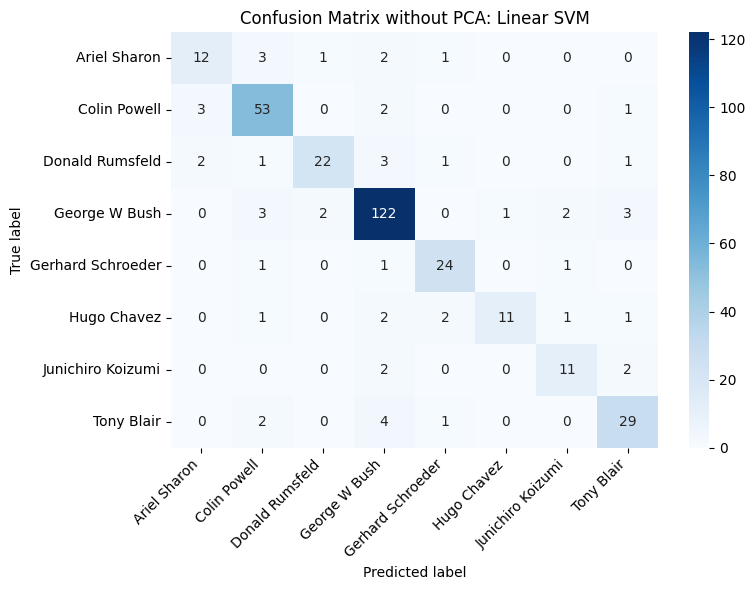

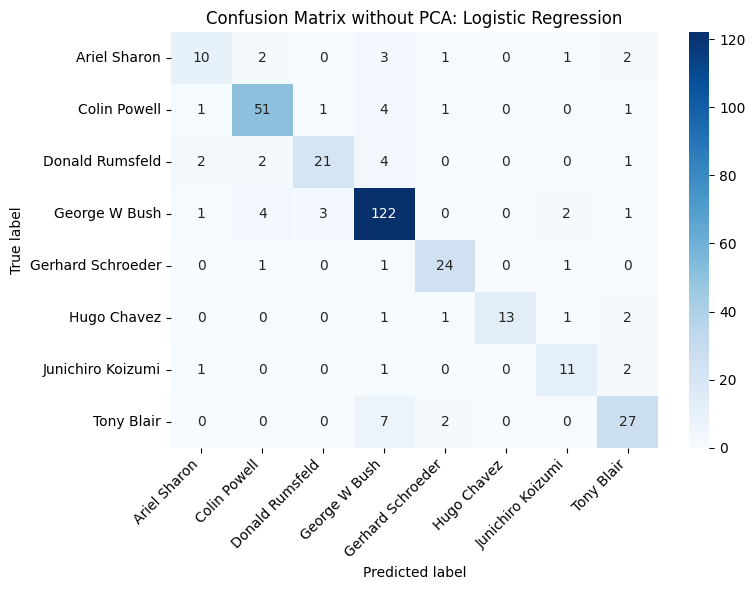

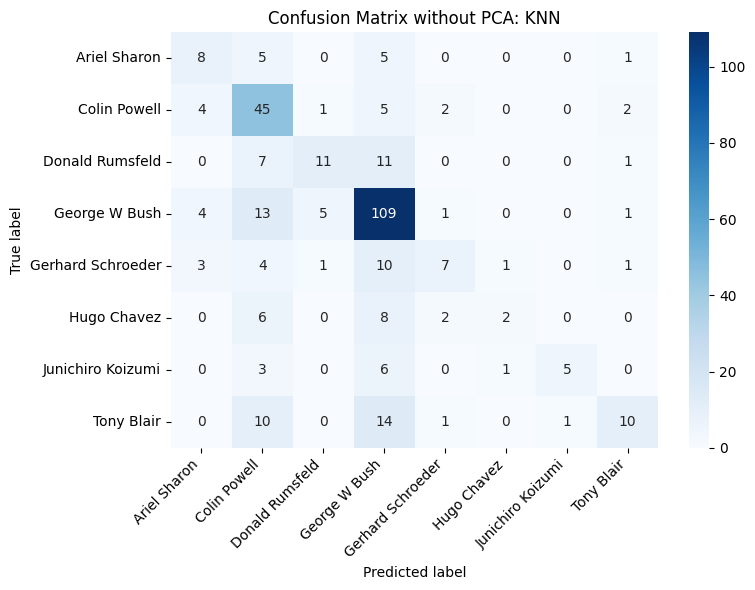

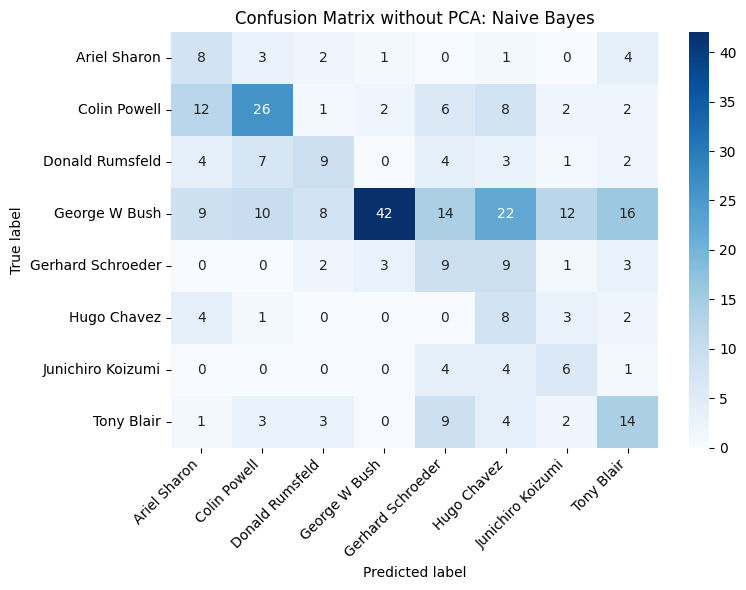

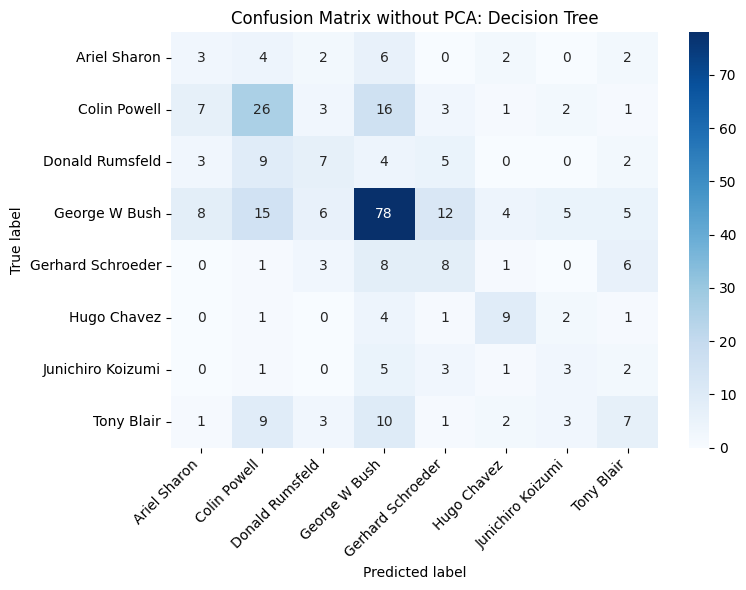

In [10]:
#confusion matrix without dimensionality and without pca

for name in classifiers.keys():
    y_pred = models_without_pca[name]["y_pred"]

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=target_names,
        yticklabels=target_names
    )

    plt.title(f"Confusion Matrix without PCA: {name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()


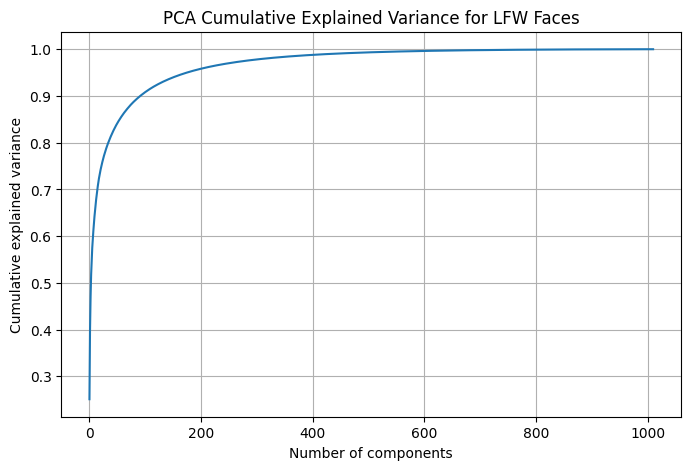

In [14]:
# Scale the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Fit PCA without limiting number of components
pca = PCA().fit(X_train_scaled)

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Cumulative Explained Variance for LFW Faces")
plt.grid(True)
plt.show()

In [21]:
#train with dimensionality reduction and pca

n_components = 0.95

pca = PCA(
    n_components=n_components,
    whiten=True,
    random_state=42
)

pca.fit(StandardScaler().fit_transform(X_train))

print("Original number of features:", X_train.shape[1])
print("Reduced number of features:", n_components)
print("Total explained variance:", np.sum(pca.explained_variance_ratio_))

Original number of features: 2914
Reduced number of features: 0.95
Total explained variance: 0.9501758


In [22]:
results_with_pca = []

models_with_pca = {}

for name, clf in classifiers.items():
    print("=" * 80)
    print("Model with PCA:", name)

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components, whiten=True, random_state=42)),
        ("classifier", clf)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results_with_pca.append({
        "Model": name,
        "Dimensionality Reduction": "With PCA",
        "Accuracy": acc
    })

    models_with_pca[name] = {
        "model": pipeline,
        "y_pred": y_pred
    }

    print("Accuracy:", acc)
    print()
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))

Model with PCA: Linear SVM
Accuracy: 0.7833827893175074

Classification Report:
                   precision    recall  f1-score   support

     Ariel Sharon       0.71      0.63      0.67        19
     Colin Powell       0.71      0.92      0.80        59
  Donald Rumsfeld       0.69      0.60      0.64        30
    George W Bush       0.85      0.83      0.84       133
Gerhard Schroeder       0.82      0.85      0.84        27
      Hugo Chavez       0.87      0.72      0.79        18
Junichiro Koizumi       0.85      0.73      0.79        15
       Tony Blair       0.72      0.64      0.68        36

         accuracy                           0.78       337
        macro avg       0.78      0.74      0.75       337
     weighted avg       0.79      0.78      0.78       337

Model with PCA: Logistic Regression
Accuracy: 0.8071216617210683

Classification Report:
                   precision    recall  f1-score   support

     Ariel Sharon       0.80      0.63      0.71        19
 

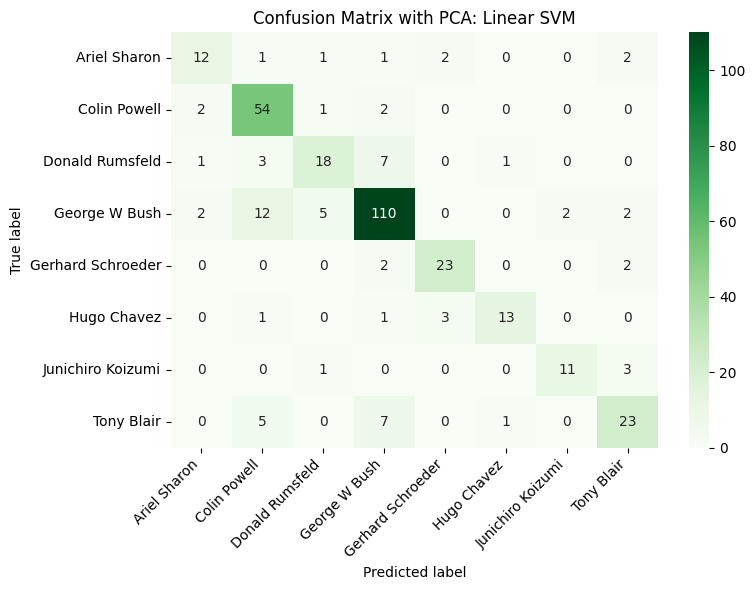

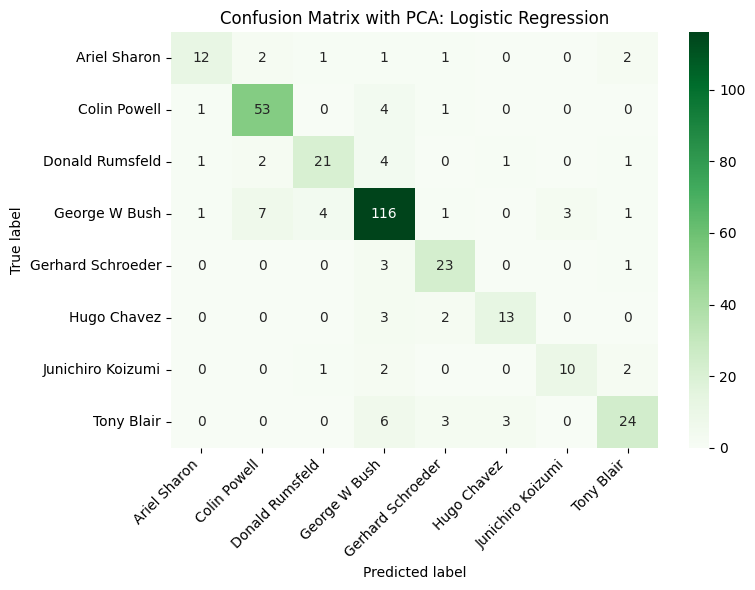

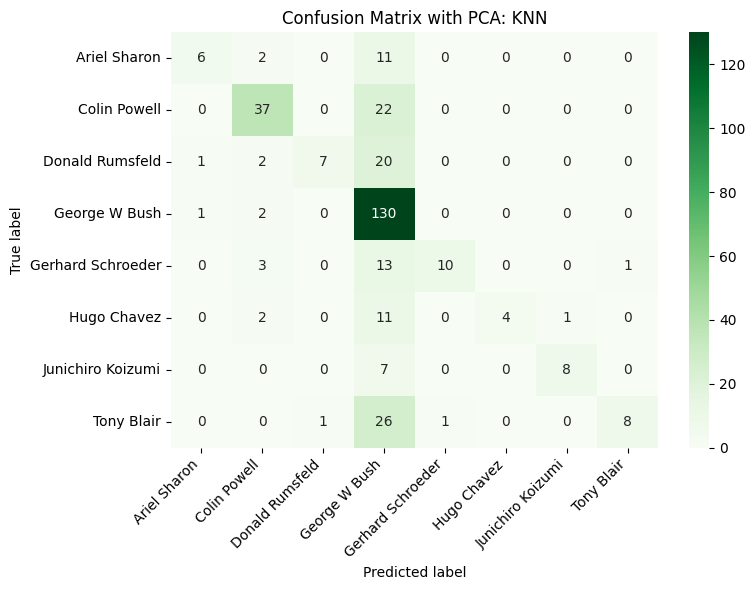

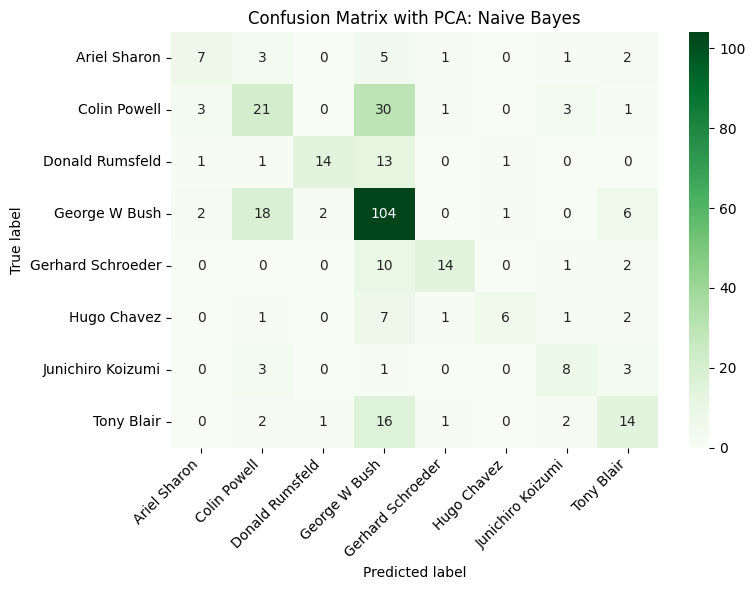

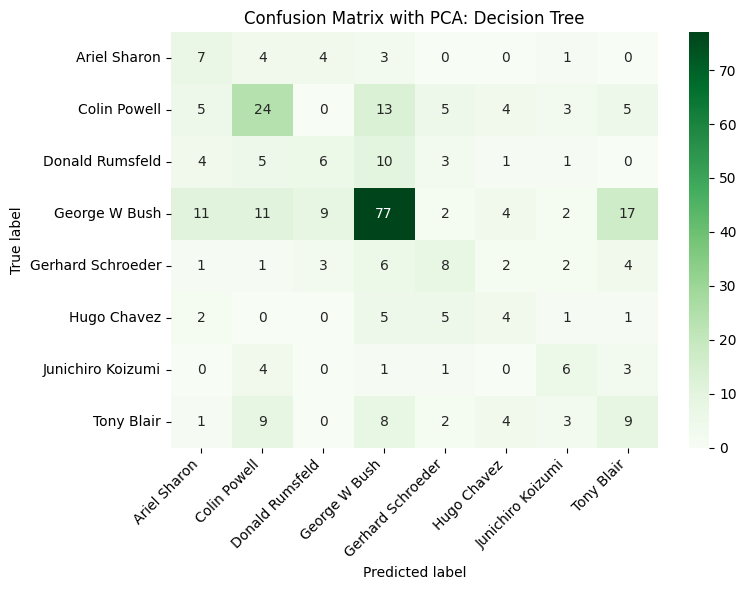

In [23]:
for name in classifiers.keys():
    y_pred = models_with_pca[name]["y_pred"]

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=target_names,
        yticklabels=target_names
    )

    plt.title(f"Confusion Matrix with PCA: {name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [25]:
#compare accuracy with and without pca

results_df = pd.DataFrame(results_without_pca + results_with_pca)
accuracy_comparison = results_df.pivot(
    index="Model",
    columns="Dimensionality Reduction",
    values="Accuracy"
)

accuracy_comparison

Dimensionality Reduction,No PCA,With PCA
Model,,
Decision Tree,0.418398,0.418398
KNN,0.584570,0.623145
Linear SVM,0.842730,0.783383
Logistic Regression,0.827893,0.807122
Naive Bayes,0.362018,0.557864


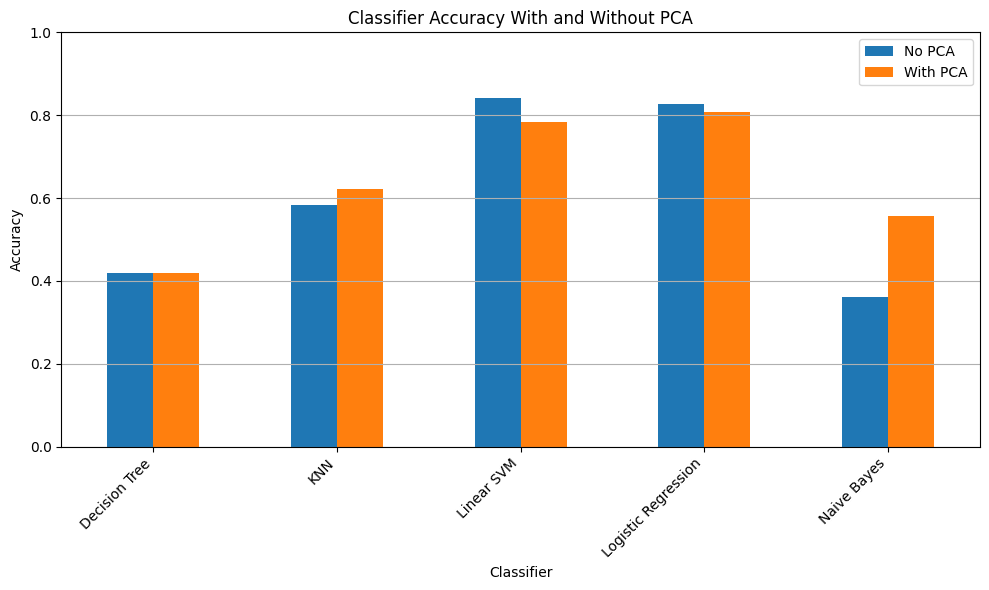

In [26]:
accuracy_comparison.plot(kind='bar', figsize=(10, 6))

plt.title("Classifier Accuracy With and Without PCA")
plt.ylabel("Accuracy")
plt.xlabel("Classifier")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.legend(title="")
plt.tight_layout()
plt.show()
